# FRAUD DETECTION

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
df = pd.read_csv("Fraud_Analysis_Dataset(in).csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


## Exploratory Data Analysis

- Dataset Overview & Structure

In [16]:
print("Shape of dataset:", df.shape)
print("\nColumn Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())
df.describe()

Shape of dataset: (11142, 10)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


- Fraud Distribution Analysis (Target Variable Analysis)

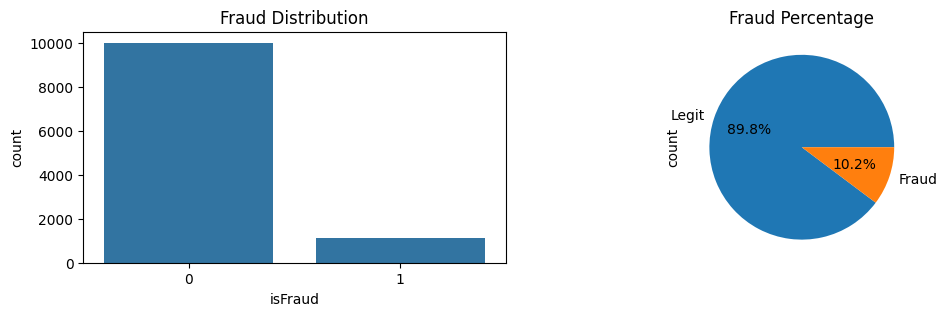

In [ ]:
plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
sns.countplot(x='isFraud', data=df)
plt.title("Fraud Distribution")

plt.subplot(1,2,2)
df['isFraud'].value_counts().plot.pie(autopct='%1.1f%%',labels=['Legit','Fraud'])
plt.title("Fraud Percentage")
plt.show()

- Fraud Analysis by Transaction Type & Amount

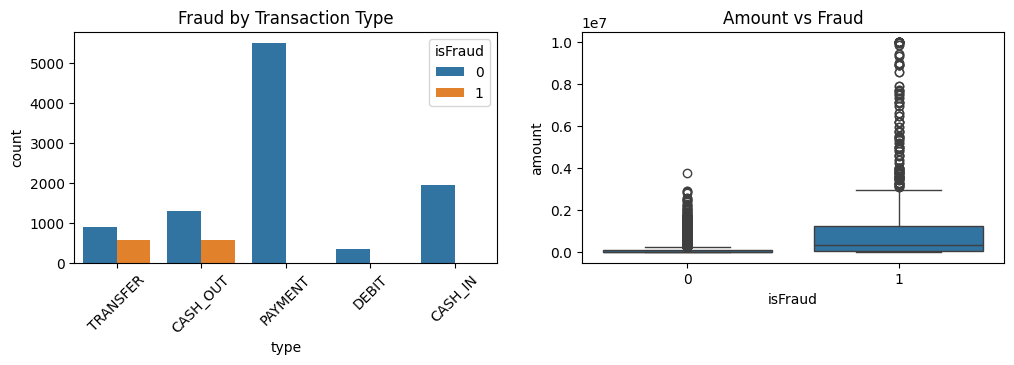

In [18]:
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount vs Fraud")

plt.show()

- Account Balance Analysis

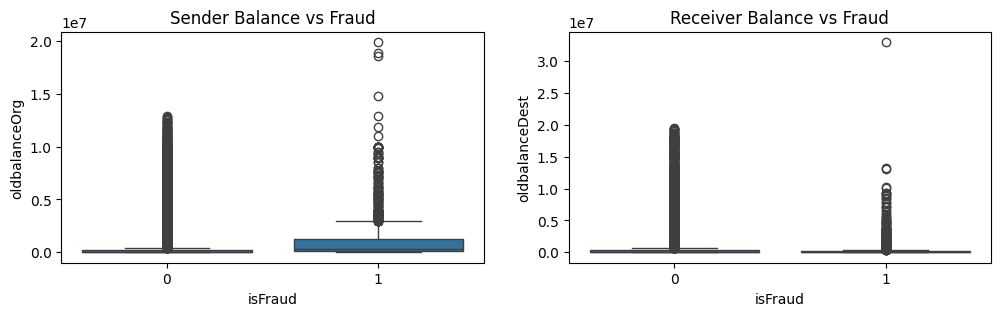

In [19]:
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
sns.boxplot(x='isFraud', y='oldbalanceOrg', data=df)
plt.title("Sender Balance vs Fraud")

plt.subplot(1,2,2)
sns.boxplot(x='isFraud', y='oldbalanceDest', data=df)
plt.title("Receiver Balance vs Fraud")

plt.show()

- Fraud Occurrence Over Time

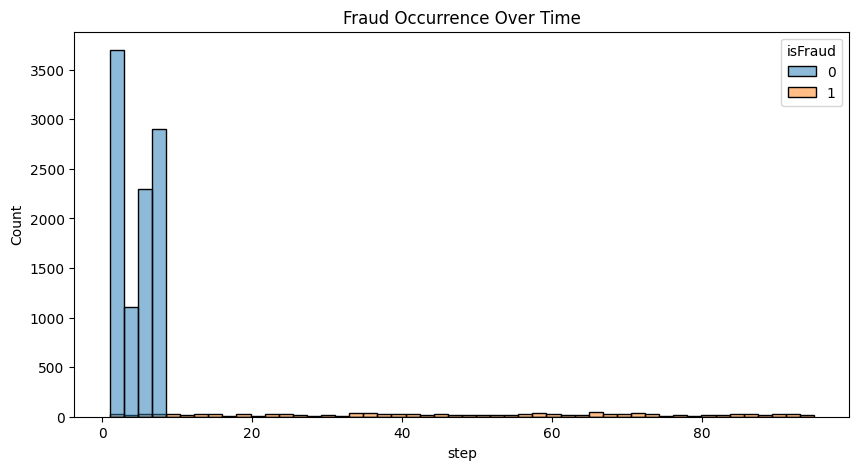

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="step", hue="isFraud", bins=50)
plt.title("Fraud Occurrence Over Time")
plt.show()

- Feature Correlation Analysis

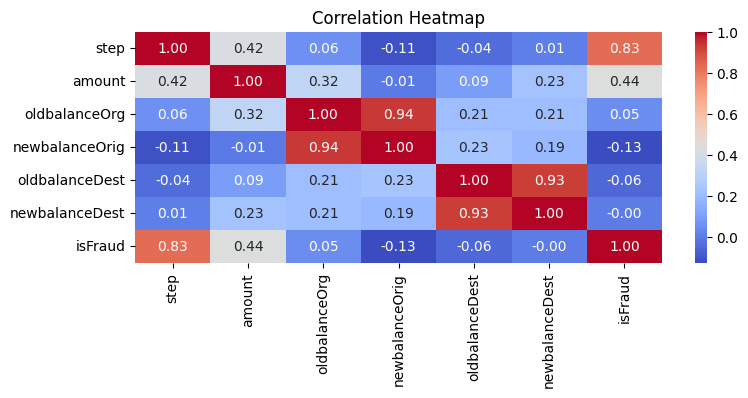

In [21]:
plt.figure(figsize=(8.5,3))

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

In [ ]:
data = df.copy()
data.drop(['nameOrig', 'nameDest'],axis=1,inplace=True)

# Amount vs sender balance
data['amount_to_oldbalanceOrg'] =(data['amount'] / (data['oldbalanceOrg'] + 1))

#transaction type risk flag
high_risk_types = ['TRANSFER', 'CASH_OUT']

data['isHighRiskType'] = data['type'].apply(lambda x: 1 if x in high_risk_types else 0)

#transaction time buckets
data['time_bucket'] = pd.cut(data['step'],bins=5,labels=['Very_Early','Early','Mid','Late','Very_Late'])

# Amount category
data['amount_category'] = pd.cut(data['amount'],bins=[0, 10000, 50000, 100000, 500000, data['amount'].max()],labels=['Very_Low','Low','Medium','High','Very_High'])

# Sender balance error
data['balanceOrig_error'] = ( data['oldbalanceOrg']- data['newbalanceOrig']- data['amount'])

# Receiver balance error
data['balanceDest_error'] = (data['newbalanceDest']- data['oldbalanceDest']- data['amount'])

### Feature - Target Split

In [ ]:
data.drop(['newbalanceOrig','newbalanceDest','step','time_bucket'], axis=1, inplace=True, errors= 'ignore')

X = data.drop('isFraud', axis=1)
y = data['isFraud']


### Train - Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25,stratify=y_temp,random_state=42)

### Data Preprocessing

- 1.1 Handling Categorical Variables

In [6]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

### Define Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced'),

    "Decision Tree": DecisionTreeClassifier(random_state=42,class_weight='balanced'),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss'
    )
}

### Model Training and Prediction Pipeline

In [ ]:
import numpy as np
from sklearn.metrics import (precision_recall_curve, roc_auc_score, average_precision_score)

results = []

for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:
        X_tr = X_train_scaled
        X_v  = X_val_scaled
    else:
        X_tr = X_train
        X_v  = X_val

    model.fit(X_tr, y_train)

    y_val_prob = model.predict_proba(X_v)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    results.append({
        "Model": name,
        "Best_Threshold": best_threshold,
        "Val_F1": f1_scores[best_idx],
        "Val_ROC_AUC": roc_auc_score(y_val, y_val_prob),
        "Val_PR_AUC": average_precision_score(y_val, y_val_prob)
    })

comparison_df = pd.DataFrame(results).sort_values(
    by="Val_PR_AUC",
    ascending=False
)

comparison_df

,Model,Best_Threshold,Val_F1,Val_ROC_AUC,Val_PR_AUC
3,XGBoost,0.936546,0.991189,0.998718,0.994489
2,Random Forest,0.385000,0.989011,0.994956,0.989979
1,Decision Tree,1.000000,0.984683,0.990516,0.971399
0,Logistic Regression,0.783101,0.867769,0.991812,0.939917


### Best Model Selection & Threshold Evaluation

In [ ]:
best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]
best_threshold = best_row["Best_Threshold"]

best_model = models[best_model_name]

if best_model_name in ["Logistic Regression", "SVM"]:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

### Performance Metrics at Default Threshold (0.5)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
y_pred_05 = (y_val_prob >= 0.5).astype(int)

precision_05 = precision_score(y_val, y_pred_05)
recall_05 = recall_score(y_val, y_pred_05)
f1_05 = f1_score(y_val, y_pred_05)
cm_05 = confusion_matrix(y_val, y_pred_05)

print("Threshold 0.5")
print("Precision:", precision_05)
print("Recall:", recall_05)
print("F1:", f1_05)
print("Confusion Matrix:\n", cm_05)

Threshold 0.5
Precision: 0.9911894273127754
Recall: 0.982532751091703
F1: 0.9868421052631579
Confusion Matrix:
 [[1998    2]
 [   4  225]]


### Performance Metrics at Optimized Threshold (0.936546)

In [11]:
optimal_threshold = 0.936546

y_pred_opt = (y_val_prob >= optimal_threshold).astype(int)

precision_opt = precision_score(y_val, y_pred_opt)
recall_opt = recall_score(y_val, y_pred_opt)
f1_opt = f1_score(y_val, y_pred_opt)
cm_opt = confusion_matrix(y_val, y_pred_opt)

print("Optimal Threshold:", optimal_threshold)
print("Precision:", precision_opt)
print("Recall:", recall_opt)
print("F1:", f1_opt)
print("Confusion Matrix:\n", cm_opt)

Optimal Threshold: 0.936546
Precision: 1.0
Recall: 0.982532751091703
F1: 0.9911894273127754
Confusion Matrix:
 [[2000    0]
 [   4  225]]


In [ ]:
import joblib
joblib.dump(best_model, "best_fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")
comparison_df.to_csv("model_comparison.csv", index=False)
joblib.dump(best_model_name, "best_model_name.pkl")
print("All files saved successfully")


All files saved successfully ✅


### Evaluation on Test Set

In [ ]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_prob >= best_threshold).astype(int)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("Test PR-AUC:", average_precision_score(y_test, y_test_prob))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test ROC-AUC: 0.9978585268769123
Test PR-AUC: 0.991915366898944
[[2001    0]
 [   4  224]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.98      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      1.00      2229
weighted avg       1.00      1.00      1.00      2229



### Save best model and model comparison

In [ ]:
joblib.dump(best_model, "best_fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")
comparison_df.to_csv("model_comparison.csv", index=False)

### Best Model Evaluation Metrics TEST SET

- ROC Curve Analysis

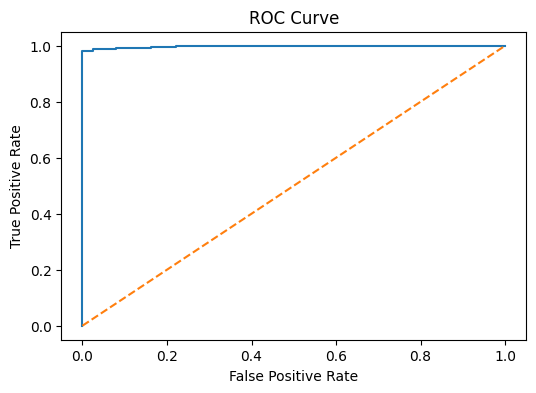

In [15]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


- Precision Recall Curve Analysis

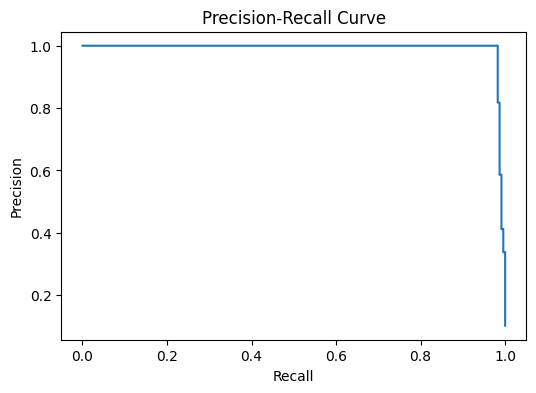

In [16]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test, y_test_prob
)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


- Confusion Matrix

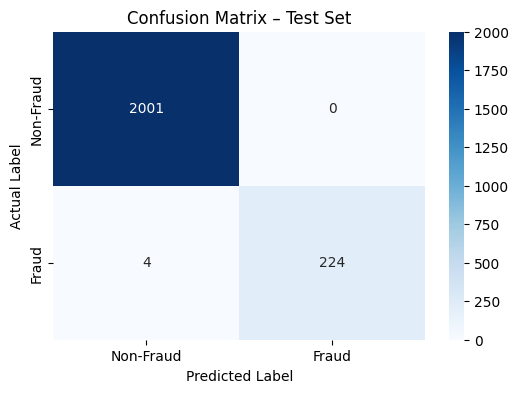

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


### Feature Importance

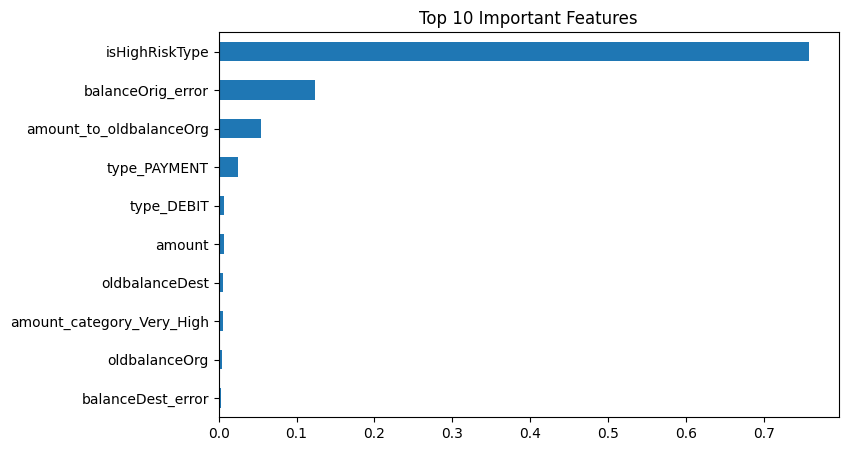

In [18]:
if hasattr(best_model, "feature_importances_"):

    importances = best_model.feature_importances_

    feat_imp = pd.Series(
        importances,
        index=X_train.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(8,5))
    feat_imp.head(10).plot(kind='barh')
    plt.title("Top 10 Important Features")
    plt.gca().invert_yaxis()
    plt.show()


### Financial Impact Analysis

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

TN, FP, FN, TP = cm.ravel()

print(f"True Positives (Fraud Caught): {TP}")
print(f"False Negatives (Missed Fraud): {FN}")
print(f"False Positives (Wrong Alerts): {FP}")
print(f"True Negatives (Legit Approved): {TN}")

test_amounts = df.loc[X_test.index, 'amount']

tp_mask = (y_test == 1) & (y_test_pred == 1)
money_saved = test_amounts[tp_mask].sum()

print(f"\nMoney Saved (Fraud Prevented): ₹{money_saved:,.2f}")

# Missed Fraud Loss

fn_mask = (y_test == 1) & (y_test_pred == 0)
missed_fraud_loss = test_amounts[fn_mask].sum()

print(f"Missed Fraud Loss: ₹{missed_fraud_loss:,.2f}")

# Investigation Cost

# Assumption: ₹100 per fraud investigation
cost_per_investigation = 100

investigation_cost = FP * cost_per_investigation

print(f"Investigation Cost (False Positives): ₹{investigation_cost:,.2f}")

# Net Financial Impact

net_profit = money_saved - missed_fraud_loss - investigation_cost

print(f"\nNet Financial Impact: ₹{net_profit:,.2f}")

True Positives (Fraud Caught): 224
False Negatives (Missed Fraud): 4
False Positives (Wrong Alerts): 0
True Negatives (Legit Approved): 2001

Money Saved (Fraud Prevented): ₹233,596,763.16
Missed Fraud Loss: ₹2,249,763.21
Investigation Cost (False Positives): ₹0.00

Net Financial Impact: ₹231,346,999.95
